# These are the linear plots for the Blue test

In [2]:
from metamers.eeg.ssvep2python import  load_ssvep_npz
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  
import pandas as pd

fname    = "MET004TESTBLUEBlueTest.mat"
targetFoder = "/home/zevaz/projects/metamers/eeg/ssvepBLUETEST"


npz_path = os.path.join(targetFoder, fname.replace(".mat", ".npz"))
ssvep =load_ssvep_npz(npz_path)


In [24]:

def plot_ssvep_sequences(ssvep_dict):
    S = ssvep_dict["SSVEPs"]        # (20, 10)
    x = ssvep_dict["blueArray"].flatten()  # (20,)
    conds = [str(c).strip("[]'") for c in ssvep_dict["conditions"].flatten()]

    plt.figure(figsize=(12, 6))

    for i, cond in enumerate(conds):
        plt.plot(x, S[:, i], label=cond, marker = "o")

    plt.xlabel("Blue intensity")
    plt.ylabel("SSVEP amplitude")
    plt.title("SSVEP sequences per condition")
    plt.xlim(min(x),max(x))
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_ssvep_subplots(ssvep_dict):
    S = ssvep_dict["SSVEPs"]
    x = ssvep_dict["blueArray"].flatten()
    conds = [str(c).strip("[]'") for c in ssvep_dict["conditions"].flatten()]

    n = S.shape[1]
    cols = 5
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(16, 8), sharex=True, sharey=True)

    for i, ax in enumerate(axes.flatten()):
        if i < n:
            ax.plot(x, S[:, i], marker = "x")
            ax.set_title(conds[i])
        else:
            ax.axis("off")

    fig.suptitle("SSVEP sequences per condition", y=1.02)
    plt.tight_layout()
    plt.xlim(min(x),max(x))
    plt.show()

def plot_ssvep_heatmap(ssvep_dict):
    S = ssvep_dict["SSVEPs"].T        # (20, 10)
    x =ssvep_dict["blueArray"].flatten()
    x_int = np.round(x).astype(int)
    conds = [str(c).strip("[]'") for c in ssvep_dict["conditions"].flatten()]

    plt.figure(figsize=(8, 6))
    sns.heatmap(S, cmap="viridis", xticklabels=x_int, yticklabels=conds)
    plt.xlabel("Blue intensity")
    plt.ylabel("Condition")
    plt.title("SSVEP amplitude heatmap")
    plt.tight_layout()
    plt.show()



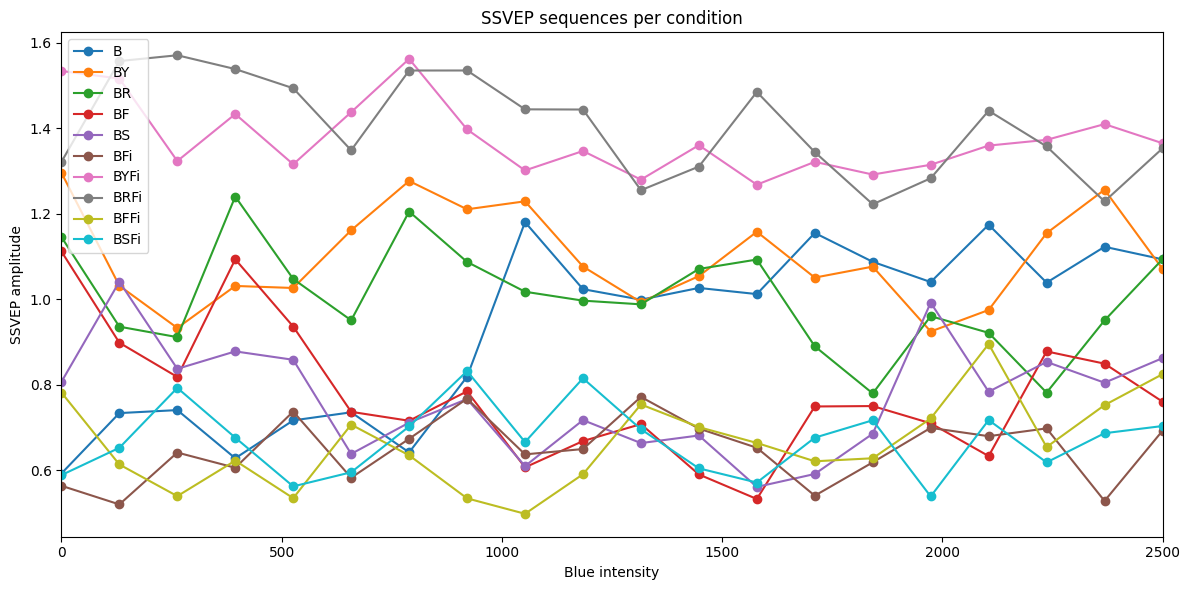

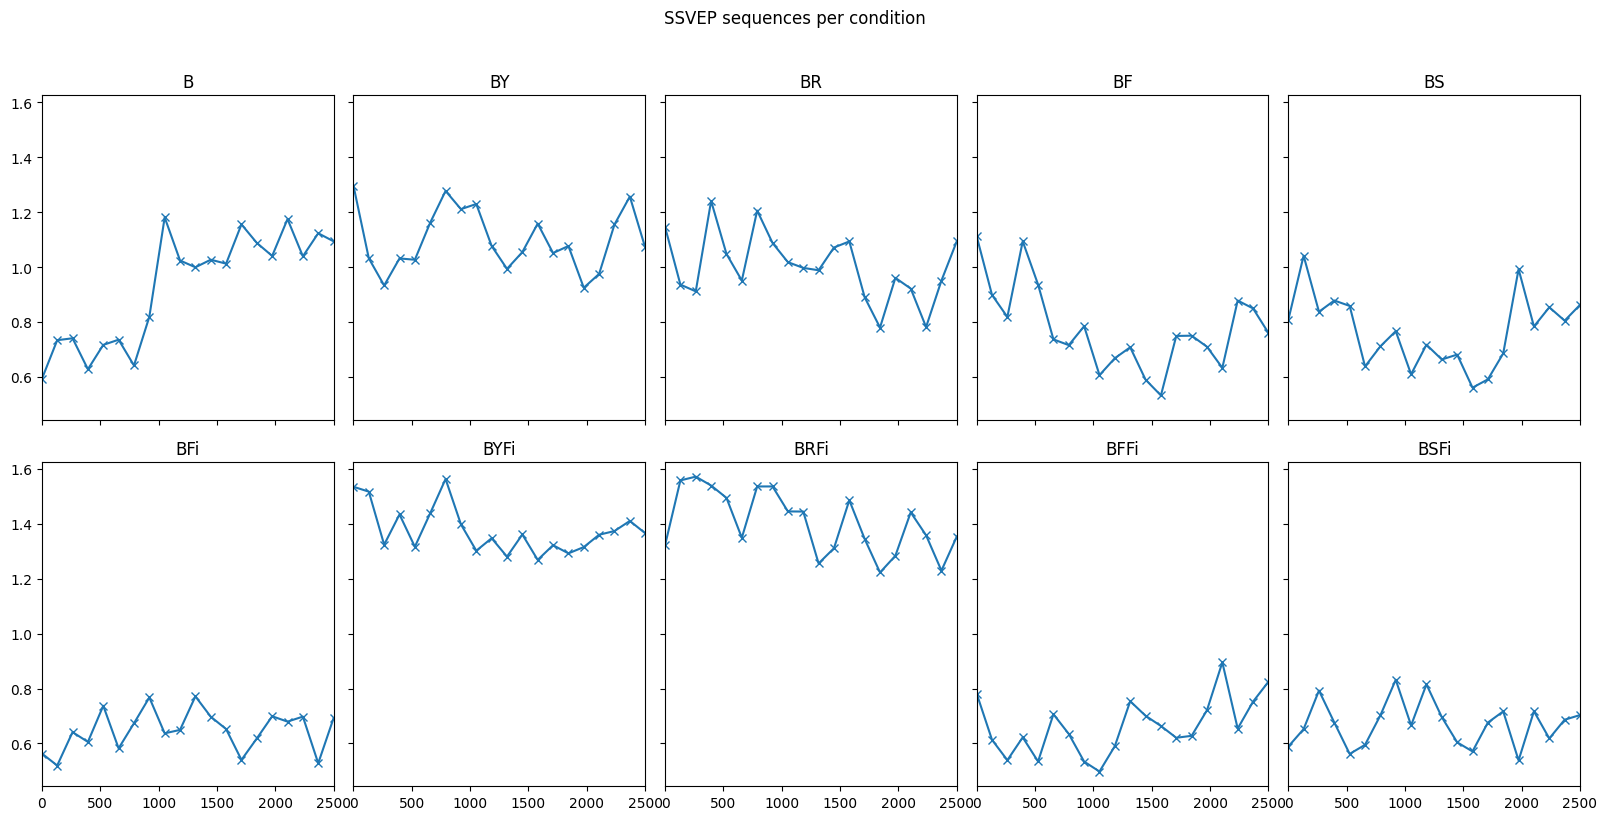

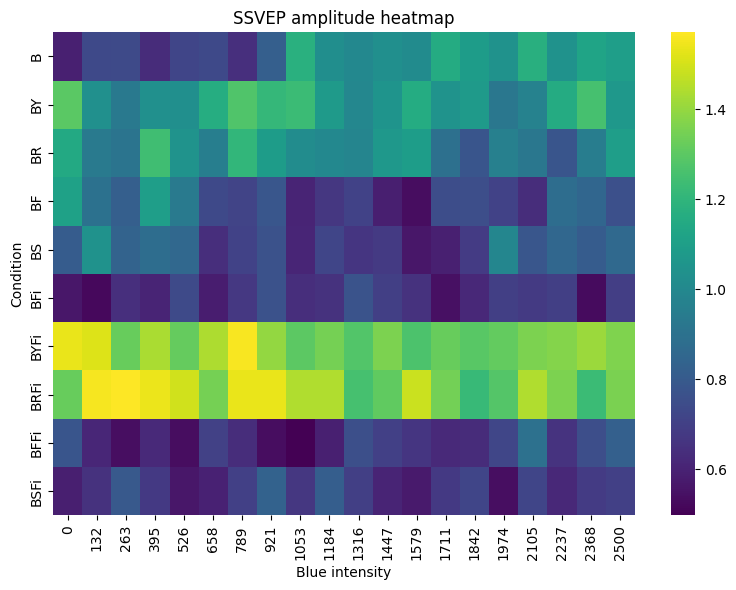

In [25]:
plot_ssvep_sequences(ssvep)
plot_ssvep_subplots(ssvep)
plot_ssvep_heatmap(ssvep)

In [45]:
raw_conditions = [str(c) for c in ssvep["conditions"].flatten()]
conditions = [ c.strip("[]'")  for c in raw_conditions]
idx = [i for i, c in enumerate(conditions) if c in["B", "BY"]]
print(idx[0])
print("Size1", len(ssvep["SSVEPs"]), "size2 ", len(ssvep["SSVEPs"][0]), len(ssvep["SSVEPs"][idx[0]]))


0
Size1 20 size2  10 10


In [83]:
def plotcomparisonslinear(ssvep, conds, title = ""):
    S       = ssvep["SSVEPs"]
    x = ssvep["blueArray"].flatten()  
    x_int = np.round(x).astype(int)

    plt.figure(figsize=(14, 6))
    idx = [i for i, c in enumerate(conditions) if c in conds]
    for i, cond in enumerate(conds):
        plt.plot(x, S[:, idx[i]], label=cond, marker = "o")
    plt.xticks(x, x_int)
    plt.xlabel("Blue intensity")
    plt.ylabel("SSVEP amplitude")
    plt.title(title)
    plt.xlim(min(x),max(x))
    plt.legend()
    plt.tight_layout()
    plt.show()

def plotcomparisonlinear_norm(ssvep, conds, title = ""):
    B = ssvep['baselines']
    S = ssvep['SSVEPs']
    x = ssvep["blueArray"].flatten()  
    x_int = np.round(x).astype(int)
    raw_conditions = [str(c) for c in ssvep["conditions"].flatten()]
    conditions = [ c.strip("[]'")  for c in raw_conditions]
    idx = [i for i, c in enumerate(conditions) if c in conds]
    plt.figure(figsize=(14, 6))
    for i, cond in enumerate(conds):
        meanBase = B[:, idx[i]].mean()
        normSSVEP = 100*((S[:,idx[i]]-meanBase)/meanBase)
        plt.plot(x, normSSVEP, label=cond, marker = "o")
    plt.xticks(x, x_int)
    plt.xlabel("Blue intensity")
    plt.ylabel("percent change SSVEP")
    plt.title(title)
    plt.xlim(min(x),max(x))
    plt.legend()
    plt.tight_layout()
    plt.show()



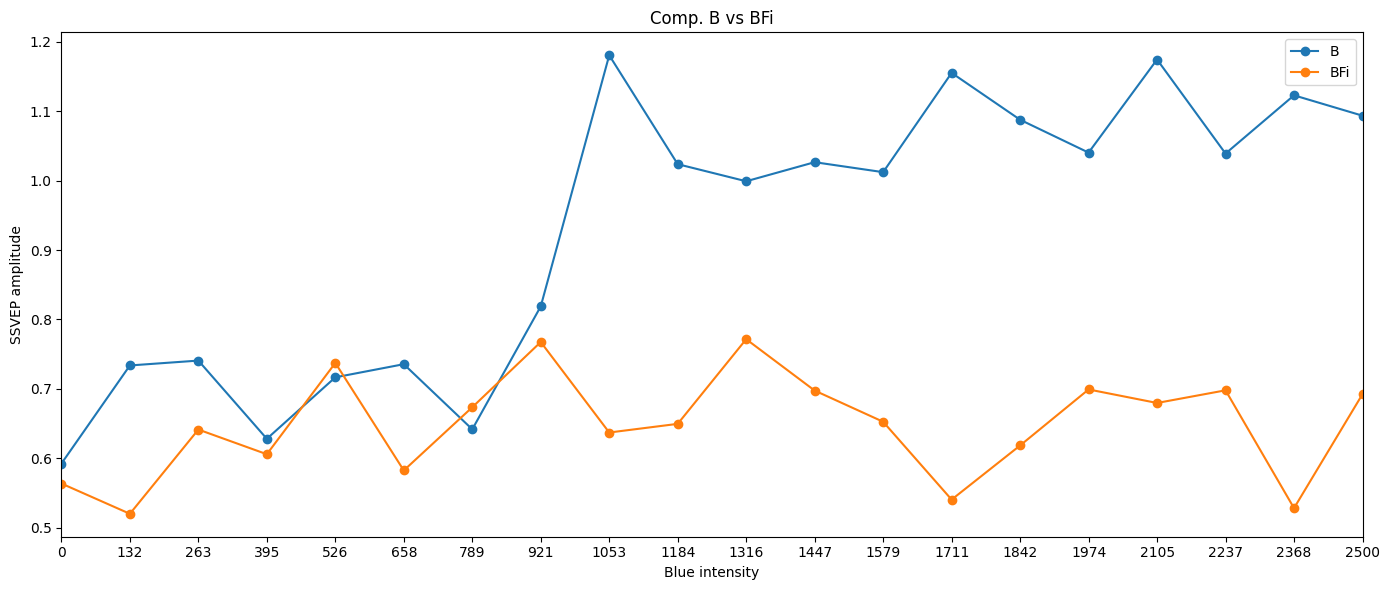

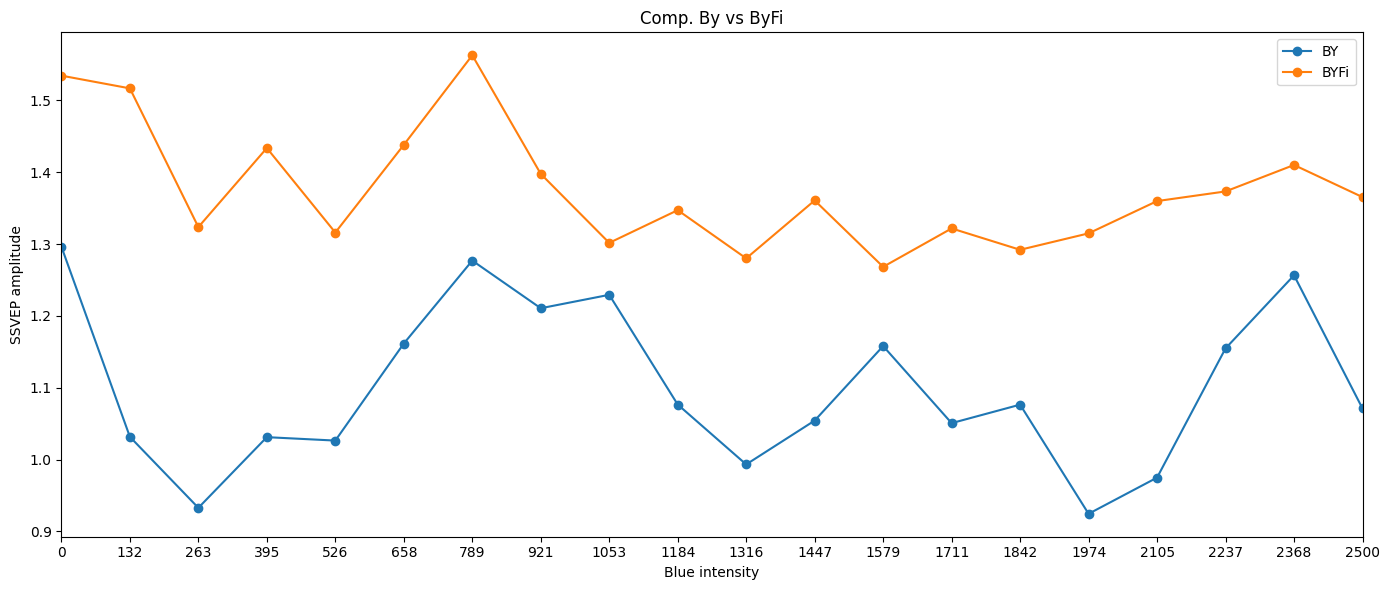

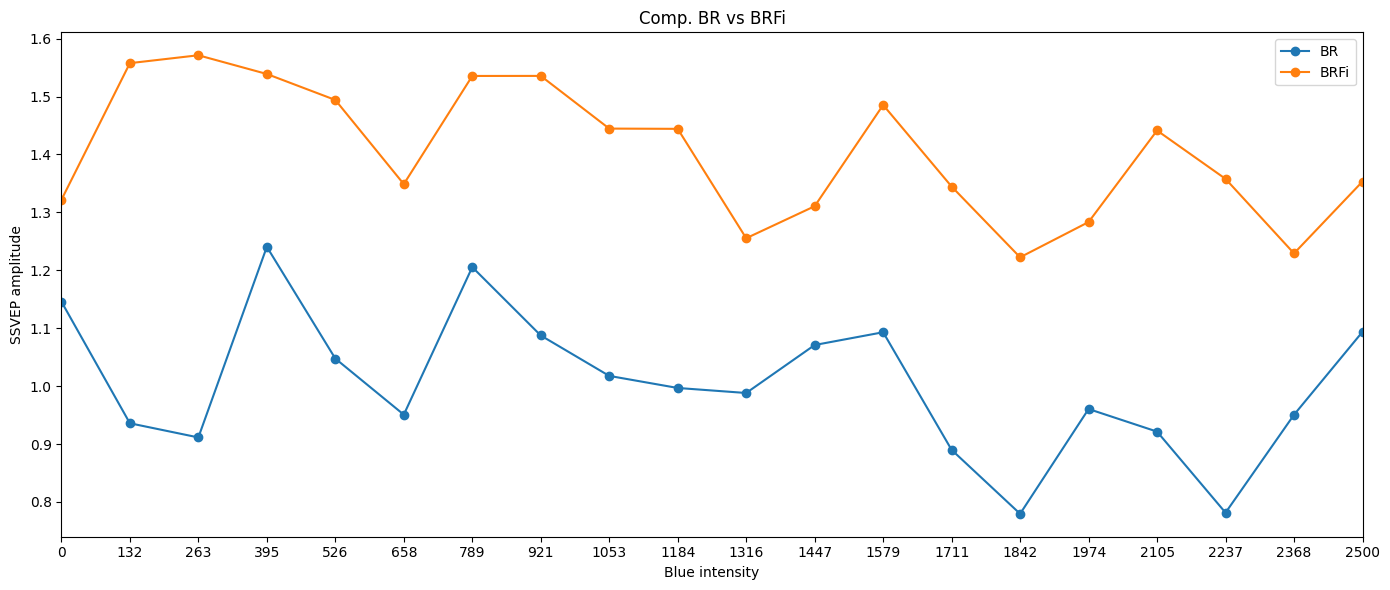

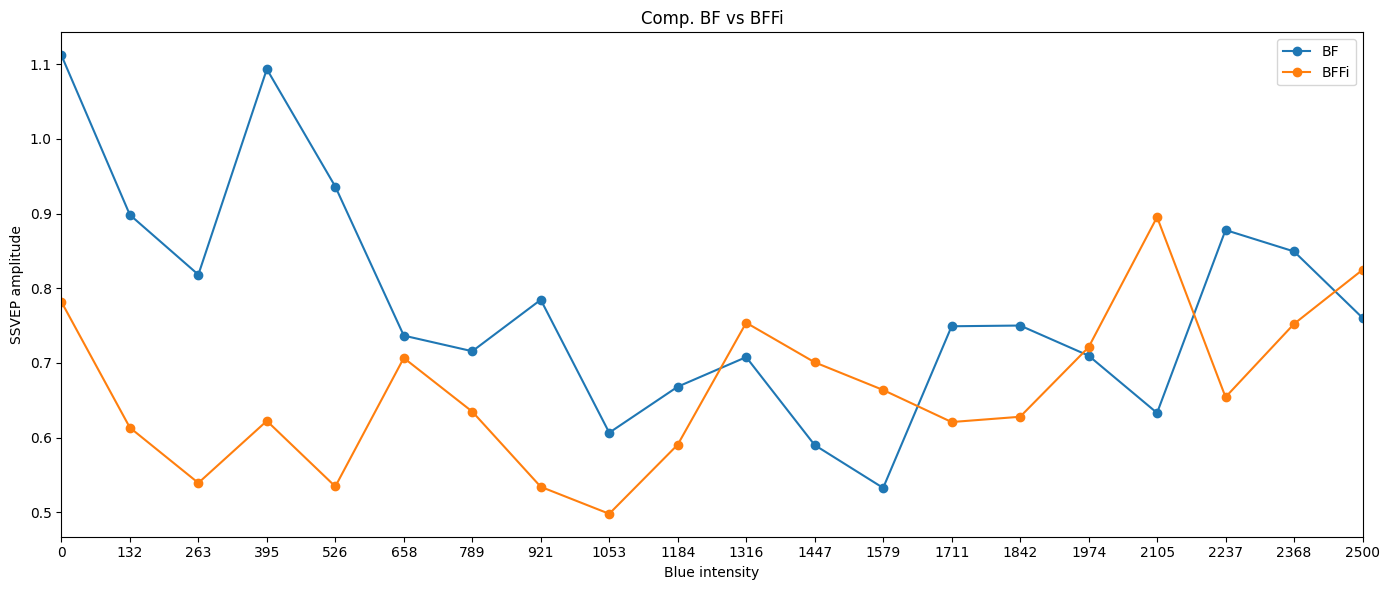

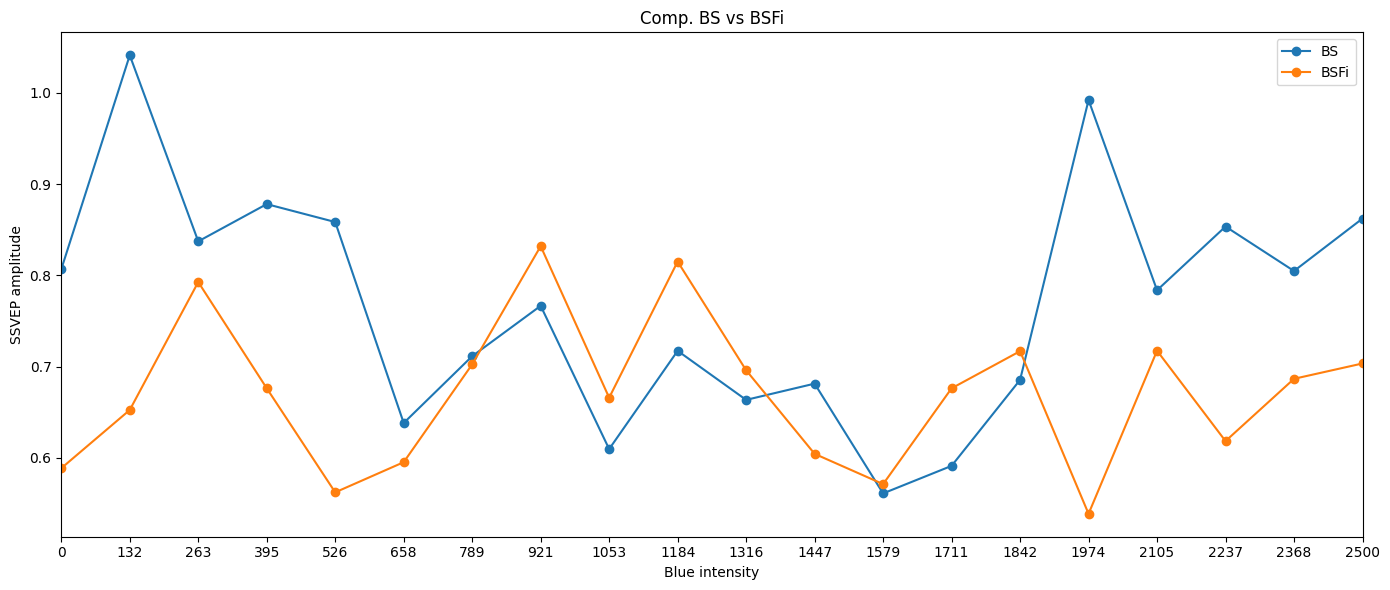

In [63]:
conds   = ["B", "BFi"]
plotcomparisonslinear(ssvep, conds, title = "Comp. B vs BFi")
conds   = ["BY", "BYFi"]
plotcomparisonslinear(ssvep, conds, title = "Comp. By vs ByFi")
conds   = ["BR", "BRFi"]
plotcomparisonslinear(ssvep, conds, title = "Comp. BR vs BRFi")
conds   = ["BF", "BFFi"]
plotcomparisonslinear(ssvep, conds, title = "Comp. BF vs BFFi")
conds   = ["BS", "BSFi"]
plotcomparisonslinear(ssvep, conds, title = "Comp. BS vs BSFi")

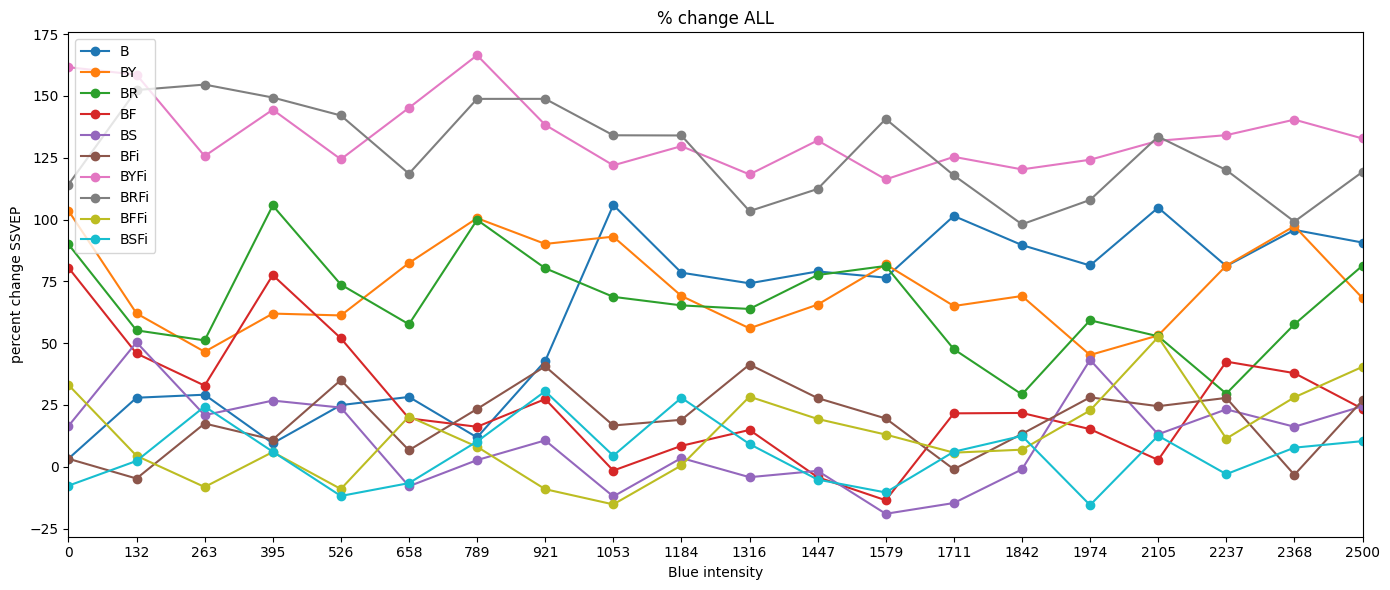

In [86]:
plotcomparisonlinear_norm(ssvep, conditions, title = "% change ALL")

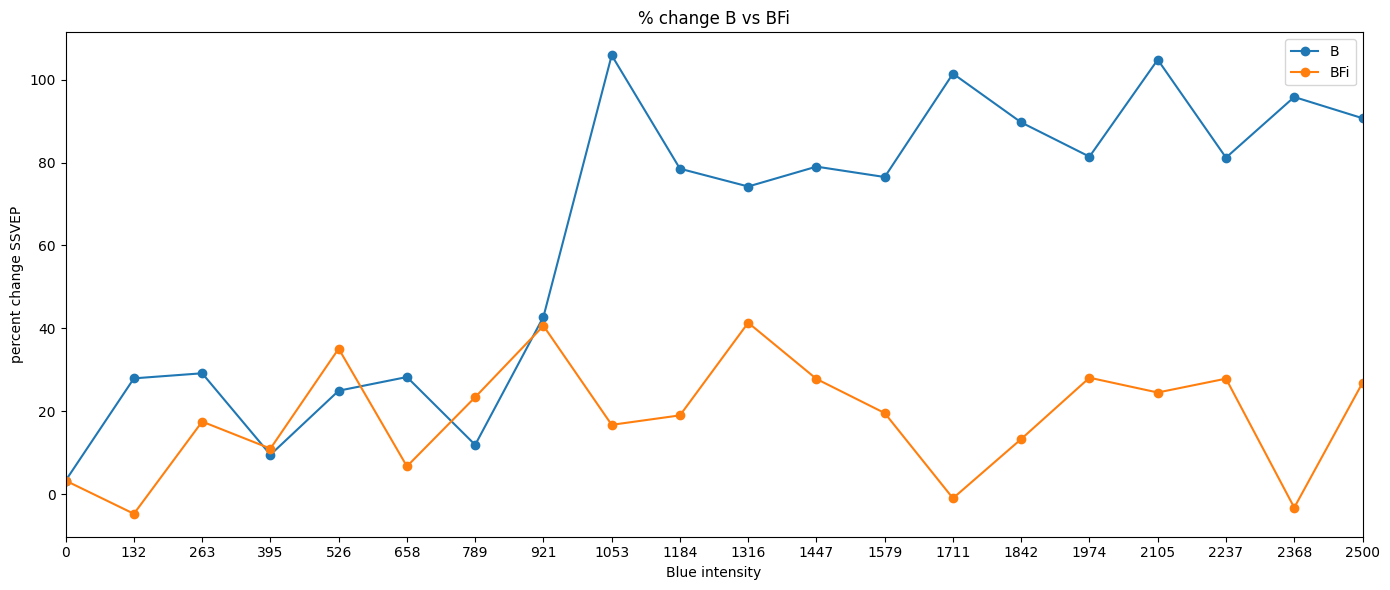

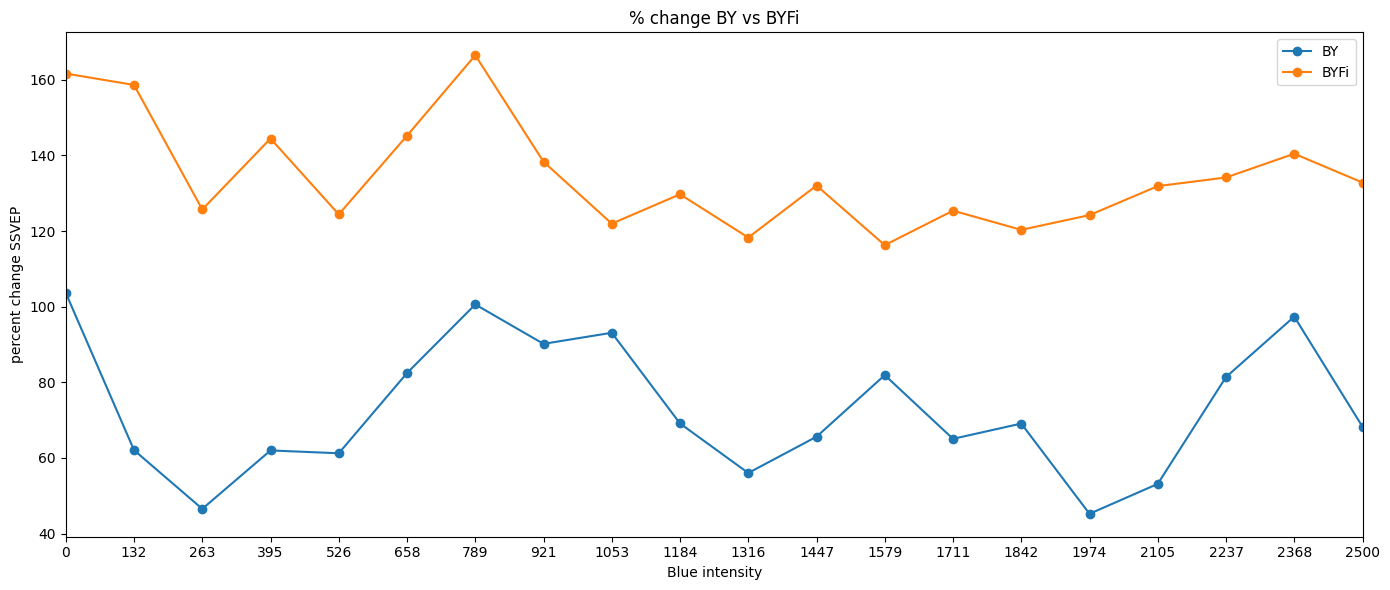

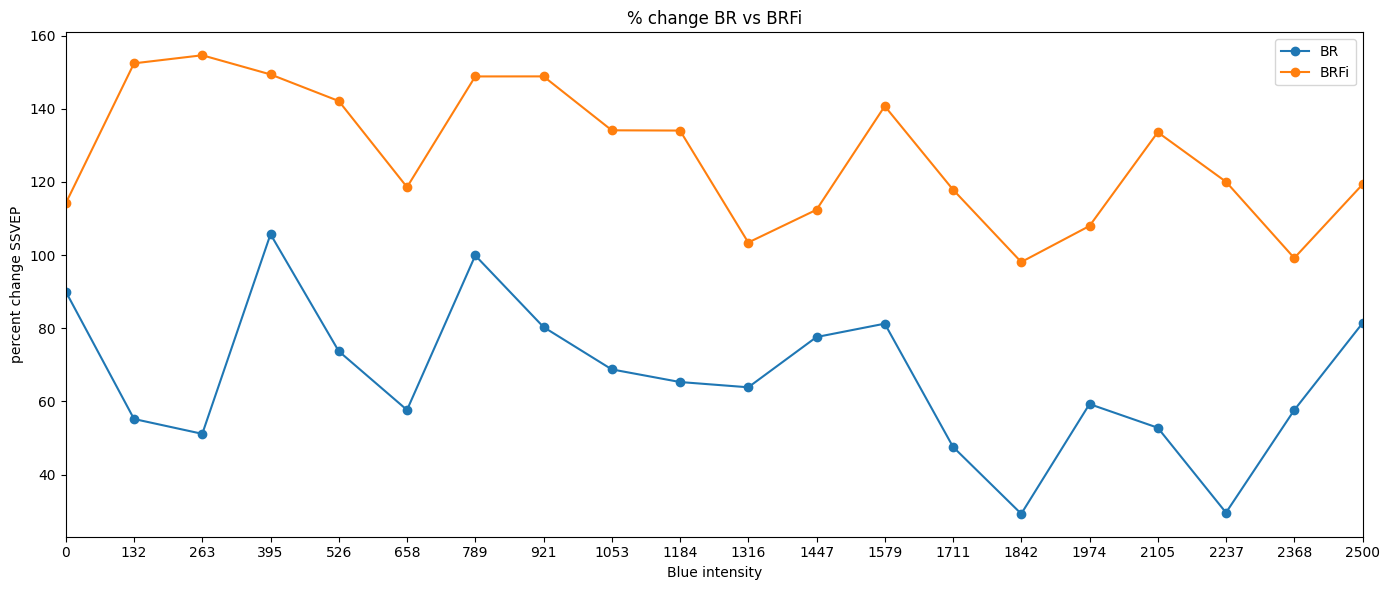

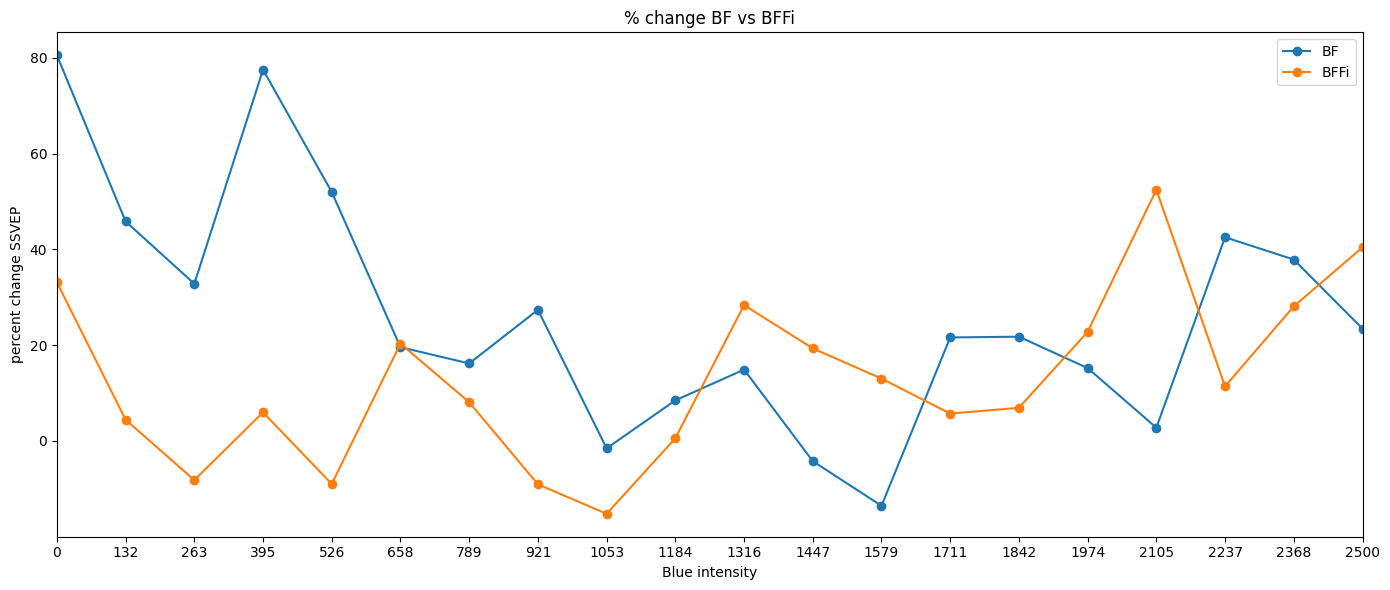

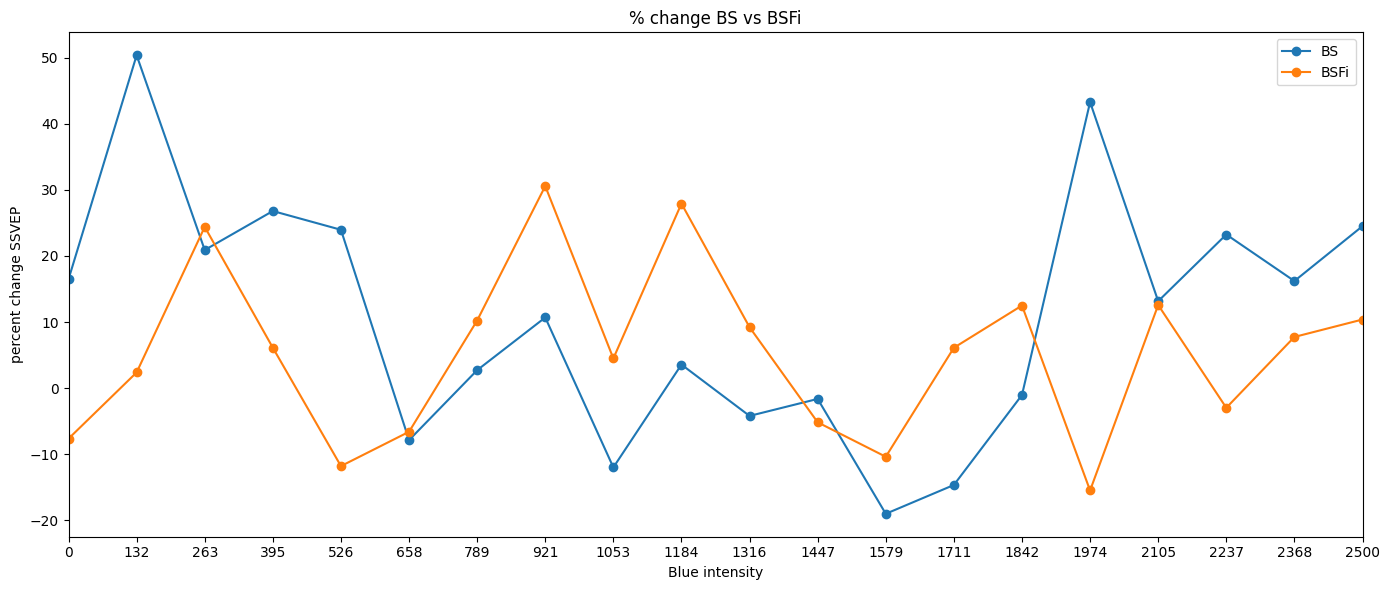

In [87]:
conds   = ["B", "BFi"]
plotcomparisonlinear_norm(ssvep, conds, title = "% change B vs BFi")
conds   = ["BY", "BYFi"]
plotcomparisonlinear_norm(ssvep, conds, title = "% change BY vs BYFi")
conds   = ["BR", "BRFi"]
plotcomparisonlinear_norm(ssvep, conds, title = "% change BR vs BRFi")
conds   = ["BF", "BFFi"]
plotcomparisonlinear_norm(ssvep, conds, title = "% change BF vs BFFi")
conds   = ["BS", "BSFi"]
plotcomparisonlinear_norm(ssvep, conds, title = "% change BS vs BSFi")